# Scenario: Modelling a Scale

![Precision scale with calibration weights](images/scale.jpg)

$$
\begin{aligned}
y \mid \sigma^2, x &\sim N(x, (x\sigma)^2) \\
\sigma^2 &\sim \mathrm{InvGamma}(\alpha, \beta) 
\end{aligned}
$$

In other words, our prior density for the variance of the relative measurement errors is $\sigma^2$:

$$
\begin{aligned}
p(\sigma^2 \mid \boldsymbol{y}) & \propto \exp()\\
& = \left( \sigma^2 \right)^{-\alpha - n/2 -1} \exp\left(-\frac{\beta + \sum_{i=1}^n \tilde{e}_i^2 /2}{\sigma^2}\right)
\end{aligned}
$$

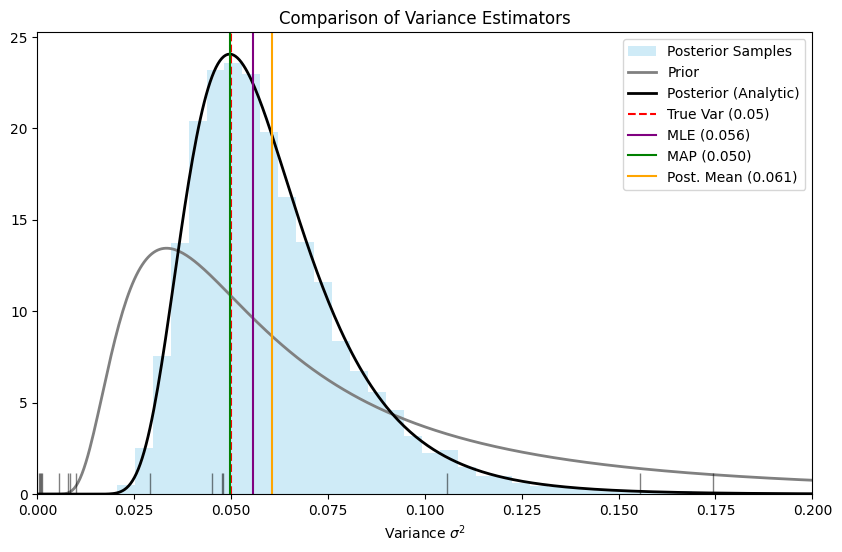

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data
np.random.seed(0)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 2) 
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))
squared_errors = (readings - true_mus)**2

# 2. Inference
alpha_prior = 2.0
beta_prior = 0.1

alpha_post = alpha_prior + len(squared_errors) / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0

# 3. Calculate Estimators
# Posterior Mean: beta / (alpha - 1)
post_mean = beta_post / (alpha_post - 1)
# Posterior Mode (MAP): beta / (alpha + 1)
post_map = beta_post / (alpha_post + 1)
# MLE: sum(errors^2) / n
mle = np.mean(squared_errors)

# 4. Sampling
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=10000)

# 5. Visualization
plt.figure(figsize=(10, 6))

# A. Histogram of Samples
plt.hist(posterior_samples, bins=60, density=True, alpha=0.4, color='skyblue', label='Posterior Samples')

# B. Analytic PDF Curves
x = np.linspace(0.0, 0.25, 500)
plt.plot(x, invgamma.pdf(x, alpha_prior, scale=beta_prior), 
         color='gray', linewidth=2, label='Prior')
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 
         color='black', linewidth=2, label='Posterior (Analytic)')

# C. Estimator Lines
plt.axvline(true_sigma2, color='red', linestyle='--', label=f'True Var ({true_sigma2})')
plt.axvline(mle, color='purple', linestyle='-', linewidth=1.5, label=f'MLE ({mle:.3f})')
plt.axvline(post_map, color='green', linestyle='-', linewidth=1.5, label=f'MAP ({post_map:.3f})')
plt.axvline(post_mean, color='orange', linestyle='-', linewidth=1.5, label=f'Post. Mean ({post_mean:.3f})')

# D. Data (Rug Plot)
plt.plot(squared_errors, np.zeros_like(squared_errors), '|k', markersize=30, alpha=0.5)

plt.xlabel(r"Variance $\sigma^2$")
plt.legend()
plt.xlim(0, 0.2)
plt.title("Comparison of Variance Estimators")
plt.show()

Acceptance Rate: 60.96% (Target usually 20-50%)


<>:102: SyntaxWarning: invalid escape sequence '\s'
<>:102: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/264071174.py:102: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Variance $\sigma^2$")


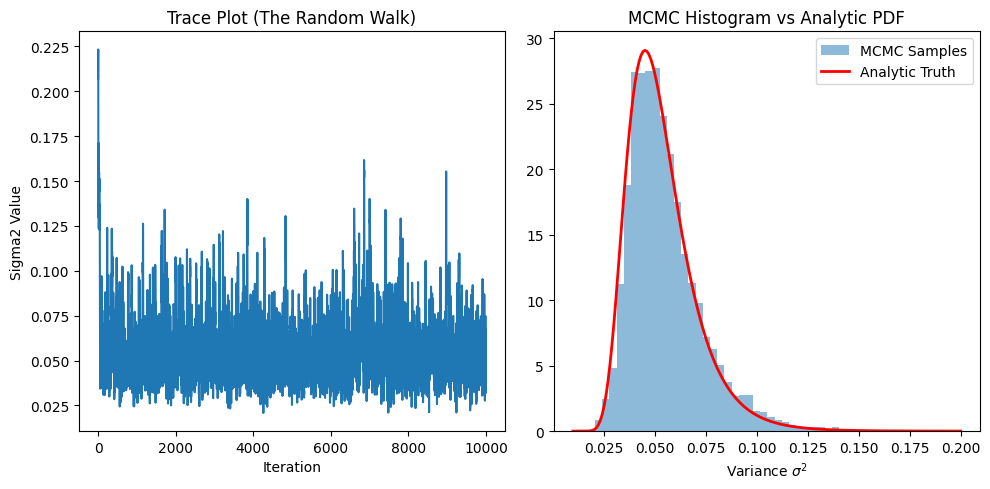

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm

# 1. Setup Data (Same as before)
np.random.seed(2026)
n_samples = 20
true_sigma2 = 0.05
# We assume we have already transformed to errors ~ N(0, sigma2)
errors = np.random.normal(0, np.sqrt(true_sigma2), size=n_samples)
squared_errors = errors**2

# Prior Parameters
alpha_prior = 2.0
beta_prior = 0.1

# ---------------------------------------------------------
# 2. Define the Unnormalized Posterior (in Log Space)
# ---------------------------------------------------------
def log_prior(sigma2):
    if sigma2 <= 0: return -np.inf # Impossible region
    # Log pdf of Inverse Gamma
    return invgamma.logpdf(sigma2, alpha_prior, scale=beta_prior)

def log_likelihood(sigma2, data_squared_errors):
    if sigma2 <= 0: return -np.inf
    n = len(data_squared_errors)
    # Log Likelihood of N(0, sigma^2)
    # -n/2 * log(2*pi*sigma^2) - sum(e^2)/(2*sigma^2)
    return - (n/2) * np.log(2 * np.pi * sigma2) - np.sum(data_squared_errors) / (2 * sigma2)

def log_posterior_unnorm(sigma2, data):
    lp = log_prior(sigma2)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(sigma2, data)

# ---------------------------------------------------------
# 3. Metropolis-Hastings Sampler
# ---------------------------------------------------------
def metropolis_hastings(n_iterations, initial_sigma2, proposal_width):
    samples = []
    current_sigma2 = initial_sigma2
    current_log_prob = log_posterior_unnorm(current_sigma2, squared_errors)
    
    accepted = 0
    
    for i in range(n_iterations):
        # A. Propose a new value (Gaussian random walk)
        proposal = current_sigma2 + np.random.normal(0, proposal_width)
        
        # B. Calculate acceptance probability
        # Note: If proposal <= 0, log_prob returns -inf, ensuring rejection
        proposal_log_prob = log_posterior_unnorm(proposal, squared_errors)
        
        # Ratio in log space is subtraction
        log_accept_ratio = proposal_log_prob - current_log_prob
        
        # C. Accept/Reject Step
        # We accept if log_ratio > 0 (prob > 1) 
        # OR if log(random_uniform) < log_ratio
        if np.log(np.random.rand()) < log_accept_ratio:
            current_sigma2 = proposal
            current_log_prob = proposal_log_prob
            accepted += 1
            
        samples.append(current_sigma2)
        
    return np.array(samples), accepted / n_iterations

# ---------------------------------------------------------
# 4. Run Sampling
# ---------------------------------------------------------
# Tuning: 'proposal_width' determines how far we jump. 
# Too small = slow exploration. Too large = high rejection rate.
n_iter = 10000
samples_mcmc, acc_rate = metropolis_hastings(n_iter, initial_sigma2=0.2, proposal_width=0.02)

print(f"Acceptance Rate: {acc_rate:.2%} (Target usually 20-50%)")

# 5. Visualization
plt.figure(figsize=(10, 5))

# Plot Trace (The "Walk")
plt.subplot(1, 2, 1)
plt.plot(samples_mcmc)
plt.title("Trace Plot (The Random Walk)")
plt.xlabel("Iteration")
plt.ylabel("Sigma2 Value")

# Plot Histogram vs Analytic Truth
plt.subplot(1, 2, 2)
plt.hist(samples_mcmc[1000:], bins=40, density=True, alpha=0.5, label='MCMC Samples') # Burn-in 1000

# Overlay Analytic Posterior (The "Truth" we derived earlier)
alpha_post = alpha_prior + n_samples / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0
x = np.linspace(0.01, 0.2, 200)
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 'r-', linewidth=2, label='Analytic Truth')

plt.title("MCMC Histogram vs Analytic PDF")
plt.xlabel("Variance $\sigma^2$")
plt.legend()
plt.tight_layout()
plt.show()

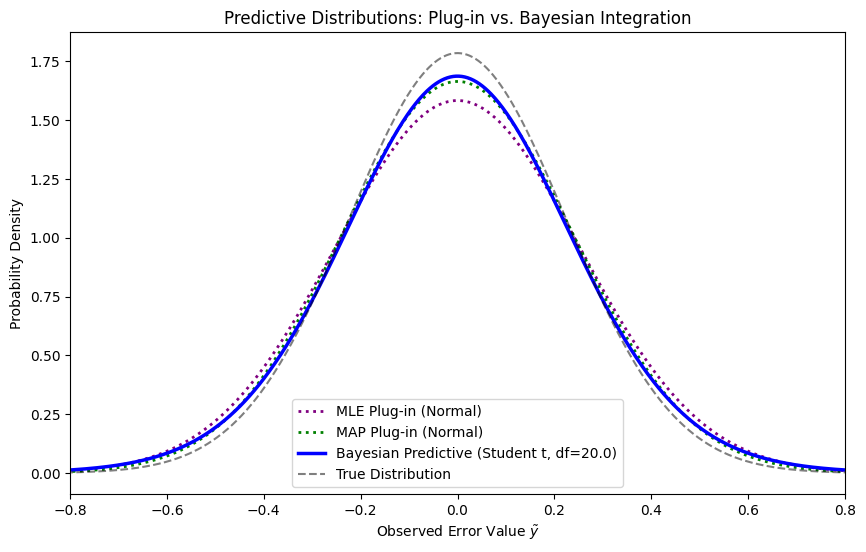

In [19]:
# ... assuming alpha_post, beta_post, mle_var, map_var are in memory ...

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Define Predictive Distributions based on Previous Inference
# A. MLE (Plug-in): Normal(0, MLE_Variance)
dist_mle = norm(loc=0, scale=np.sqrt(mle_var))

# B. MAP (Plug-in): Normal(0, MAP_Variance)
dist_map = norm(loc=0, scale=np.sqrt(map_var))

# C. Bayesian (Marginalized): Student-t(df=2*alpha_post, scale=sqrt(beta_post/alpha_post))
# We use the posterior parameters directly. No priors involved.
df_pred = 2 * alpha_post
scale_pred = np.sqrt(beta_post / alpha_post)
dist_bayes = t(df=df_pred, loc=0, scale=scale_pred)

# 2. Visualization
x_grid = np.linspace(-1.0, 1.0, 1000)

plt.figure(figsize=(10, 6))

# Plot Densities
plt.plot(x_grid, dist_mle.pdf(x_grid), 'purple', linestyle=':', linewidth=2, label='MLE Plug-in (Normal)')
plt.plot(x_grid, dist_map.pdf(x_grid), 'green', linestyle=':', linewidth=2, label='MAP Plug-in (Normal)')
plt.plot(x_grid, dist_bayes.pdf(x_grid), 'blue', linewidth=2.5, label=f'Bayesian Predictive (Student t, df={df_pred:.1f})')
plt.plot(x_grid, norm.pdf(x_grid, 0, np.sqrt(true_sigma2)), 'k--', alpha=0.5, label='True Distribution')

plt.title("Predictive Distributions: Plug-in vs. Bayesian Integration")
plt.xlabel(r"Observed Error Value $\tilde{y}$")
plt.ylabel("Probability Density")
plt.legend()
plt.xlim(-0.8, 0.8)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3565104419.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior $\sigma^2$')
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3565104419.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Error Variance ($\sigma^2$)")


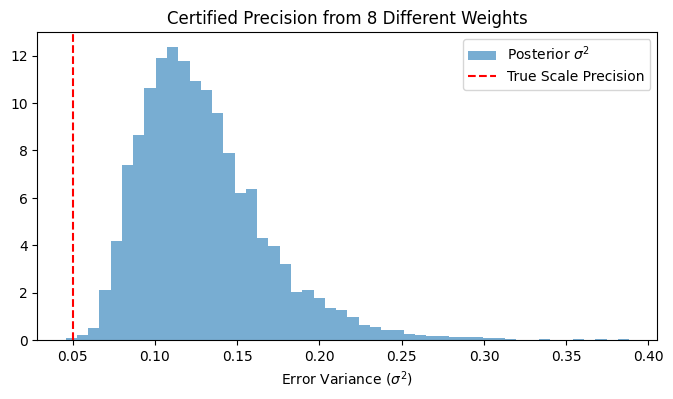

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup: A Calibration Set of different true weights
np.random.seed(42)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
# We measure each weight 3 times
true_mus = np.repeat(true_weights, 3) 

# The scale has a constant precision (noise) across the range
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))

# 2. Transform to Errors
# Since we know the true weight for every measurement, we just subtract it
# This pools all data into a single distribution centered at 0
errors = readings - true_mus

# 3. Analytic Posterior for Variance (Mean is fixed at 0)
alpha_prior = 1.0
beta_prior = 1.0

# The data term aggregates information from ALL different weights
alpha_post = alpha_prior + len(errors) / 2.0
beta_post = beta_prior + np.sum(errors**2) / 2.0

# 4. Sampling & Visualization
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior $\sigma^2$')
plt.axvline(true_sigma2, color='red', linestyle='--', label='True Scale Precision')
plt.title(f"Certified Precision from {len(true_weights)} Different Weights")
plt.xlabel("Error Variance ($\sigma^2$)")
plt.legend()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3965403058.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Error Variance ($\sigma^2$)")


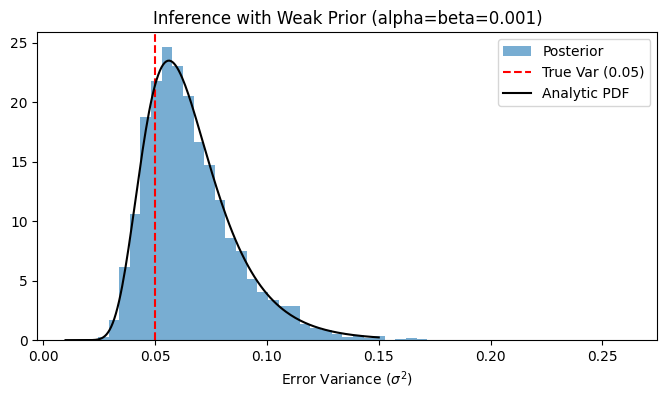

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data (Seed changed)
np.random.seed(0)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 3) 

# True precision is 0.05
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))
errors = readings - true_mus

# 2. Analytic Posterior with Weak Priors
# We set these close to 0 to minimize their influence
alpha_prior = 0.001
beta_prior = 0.001

alpha_post = alpha_prior + len(errors) / 2.0
beta_post = beta_prior + np.sum(errors**2) / 2.0

# 3. Sampling
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=5000)

# 4. Visualization
plt.figure(figsize=(8, 4))
plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior')
plt.axvline(true_sigma2, color='red', linestyle='--', label=f'True Var ({true_sigma2})')

# Analytic PDF
x = np.linspace(0.01, 0.15, 200)
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 'k-', label='Analytic PDF')

plt.title("Inference with Weak Prior (alpha=beta=0.001)")
plt.xlabel("Error Variance ($\sigma^2$)")
plt.legend()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/1896235219.py:44: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Variance $\sigma^2$ / Squared Error Value")


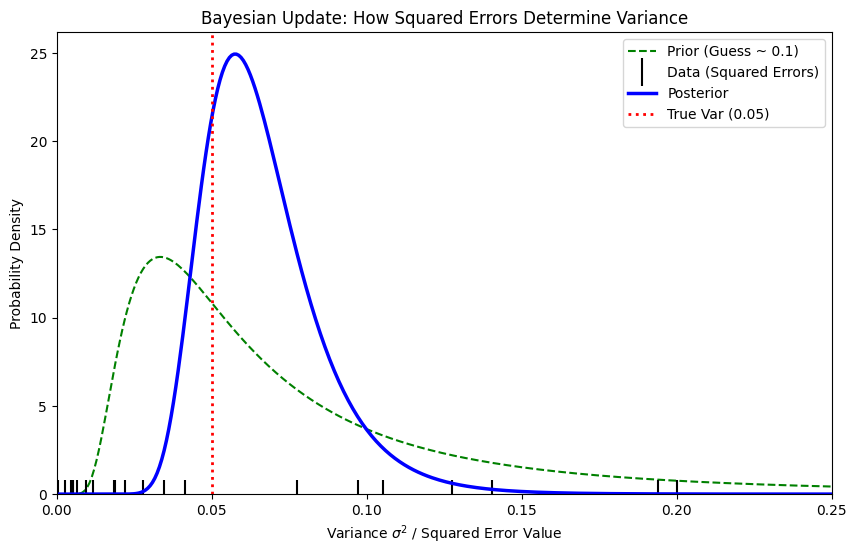

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data
np.random.seed(2026)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 3) 
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))

# The "Data" for variance inference is the Squared Error
squared_errors = (readings - true_mus)**2

# 2. Inference
# Using a visible Prior: centered at 0.1, but very flat/uncertain
alpha_prior = 2.0
beta_prior = 0.1

alpha_post = alpha_prior + len(squared_errors) / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0

# 3. Visualization
plt.figure(figsize=(10, 6))
x = np.linspace(0.0, 0.3, 400)

# A. The Prior PDF
plt.plot(x, invgamma.pdf(x, alpha_prior, scale=beta_prior), 
         'g--', label='Prior (Guess ~ 0.1)')

# B. The Data (Rug Plot of Squared Errors)
# We plot these as vertical ticks on the x-axis
plt.plot(squared_errors, np.zeros_like(squared_errors), 
         '|k', markersize=20, markeredgewidth=1.5, label='Data (Squared Errors)')

# C. The Posterior PDF
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 
         'b-', linewidth=2.5, label='Posterior')

# D. The Truth
plt.axvline(true_sigma2, color='red', linestyle=':', linewidth=2, label=f'True Var ({true_sigma2})')

plt.title("Bayesian Update: How Squared Errors Determine Variance")
plt.xlabel("Variance $\sigma^2$ / Squared Error Value")
plt.ylabel("Probability Density")
plt.legend()
plt.ylim(bottom=0) # Keep y-axis clean
plt.xlim(0, 0.25)
plt.show()